# PEN-DNA System Simulation Workflow

## I. Define the System
Specify the following parameters to model the experimental setup:

1. **Experimental Conditions**
    - Temperature
   - Buffer composition
   - Leak rates

2. **System Components**
   - Signals
   - Drains
   - Templates
   - Reporter templates

## II. Run the Simulation
Execute the simulation using the defined parameters and components, for a selected duration.

## III. Visualize Results
Plot the simulation data to analyze system behavior and outcomes.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Get the absolute path to the root directory
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)


from PEN_simulation import PEN_System
from strands import Signal, Drain, Template, Reporter, reverse_complement


## I. Define the system

In [2]:
## DEFINE THE GENERAL PARAMETERS

system = PEN_System(temperature=45,                     # Define the temperature
                    
                    sodium=0.07,                        # Define the monovalent ion concentration: Default value is 0.07 nM
                    magnesium=0.0125,                   # Define the bivalent ion concentration: Default value is 0.0125 nM

                    concentration_BsmI=300,             # Define the nickase Nb.BsmI concentration: Default value is 10 U/µL
                    concentration_NBI=10,               # Define the nickase Nt.BstNBI concentration: Default value is 45 U/µL
                    concentration_pol=30,               # Define the polymerase concentration: Default value is 25.5 U/µL (of Bst polymerase)
                    concentration_exo=23,               # Define the polymerase concentration: Default value is 50 nM (of ttRecJ exonuclease)

                    leak=0,                             # Define a leak rate. This value is arbitrary, default is 0. Recommended is around 6e-6. 
                                                        #It is also possible to define specific leak rates to each templates
                    )





## DEFINE THE COMPONENTS

# Define the Signal
alpha=Signal(name="alpha",                              # Name of the Signal
             sequence="CATTCTGGACTG",                   # Sequence of the Signal
             concentration=0,                           # Concentration of the Signal
             protected=False,                           # Is it protected against exonuclease degradation?
             IsDrained=True,                            # Is there a drain potentially deactivating the Signal (checked during simulation)
             plus=0,                                    # Is it a longer version of another Signal?
             minus=0,                                   # Is it a shorter version of another Signal?
             )  

beta=Signal(name="beta",
            sequence="CATTCAGGATCG", 
            concentration=150, 
            protected=False, 
            IsDrained=True
            )

system.add_signal(alpha)
system.add_signal(beta)


# Define the Drain template
dT=Drain(name="dT",                                     # Name of the drain template
         input=alpha,                                   # Target signal
         concentration=5,                               # Concentration of the drain template
         sequence= "TTCAGTCCAGAATG",                    # Sequence of the drain template
         protected=True                                 # Is the drain template protected against exonuclease degradation?
         )

system.add_drain(dT)


# Define the Converter Templates        
cT=Template(name="cT",                                  # Name of the converter template
            sequence="CAGTCCAGAATGCGATCCTGAATG",        # Sequence of the converter template    
            input=beta,                                 # Input signal of the converter template
            output=alpha,                               # Output signal of the converter template
            concentration=2,                            # Concentration of rhe converter template
            nick="NBI",                                 # Nickase used by the converter template 
            protected=True,                             # Is the converter template protected against exonuclease degradation?
            phosphated=False,                           # Is the converter template phosphated (protected against polymerase extensions)
            irreversible=True,                          # Is it an irreversible converter template?
            leak=5e-6                                   # Specific leak rate (optional)
            )

aT=Template(name="aT", 
            sequence="CAGTCCAGAATGCAGTCCAGAA",
            input=alpha, 
            output=alpha, 
            concentration=20, 
            nick="BsmI", 
            protected=True, 
            irreversible=False, 
            phosphated=True, 
            leak=6e-6
            )

system.add_template(aT)
system.add_template(cT)


# Define the Reporter Templates   

# Define the waste of the reporter template    
rT_waste = Signal(name="rT_waste", 
                   sequence="CATTCAGAAT", 
                   concentration=0, 
                   protected=False, 
                   IsDrained=False
                   )
system.add_signal(rT_waste)

rT_alpha=Reporter(name="rT_alpha",                          # Name of the reporter template
                    sequence="ATTCTGAATGCAGTCCAGAAT",       # Sequence of the reporter template
                    input=alpha,                            # Reported signal
                    output=rT_waste,                        # Waste of the reporter template
                    concentration=50,                       # Concentration of the reporter template
                    reversible=True,                        # Is the reporting process reversible?
                    fluorophore="FAM",                      # Fluorophore of the reporter template
                    quencher="BHQ1",                        # Quencher used in the reporter template
                    )

system.add_reporter(rT_alpha)



## II. Run the simulation

In [3]:
# Define time of the simulation
t=np.linspace(0,100,1001)

# Run the simulation
y = system.solve_system(t)

## III. Plot the results

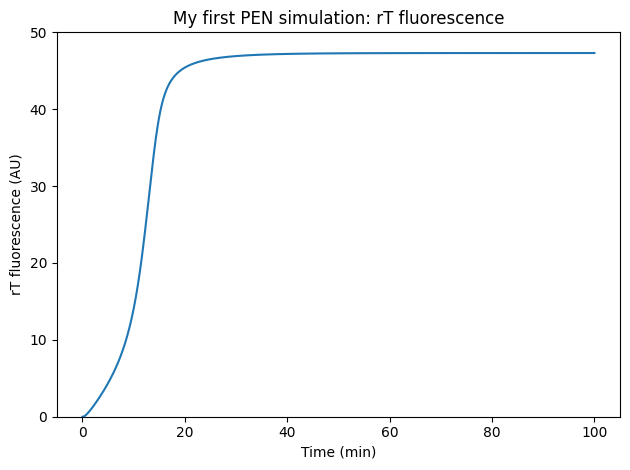

In [4]:
# Fluorescence of a reporter template
fluo=system.fluorescence_list(y, "rT_alpha")

plt.plot(t,fluo)
plt.title("My first PEN simulation: rT fluorescence")
plt.xlabel("Time (min)")
plt.ylabel("rT fluorescence (AU)")
plt.ylim(0,50)
plt.tight_layout()
plt.show()


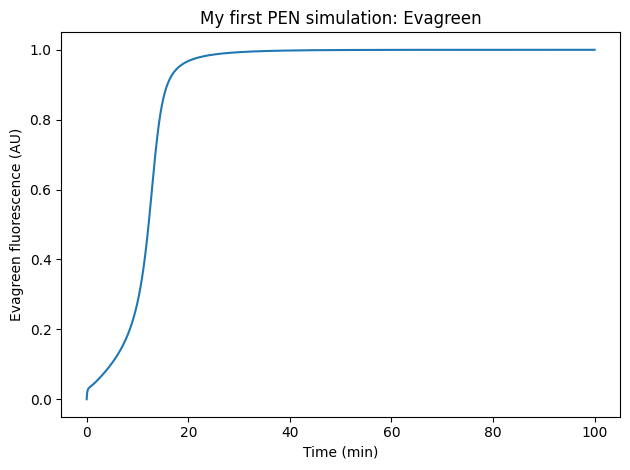

In [5]:
# Evagreen fluorescence
eva=system.concentration_list(y,"Evagreen") # extract the solution corresponding to the Evagreen fluorescence

plt.plot(t,eva)
plt.title("My first PEN simulation: Evagreen")
plt.xlabel("Time (min)")
plt.ylabel("Evagreen fluorescence (AU)")
plt.tight_layout()
plt.show()


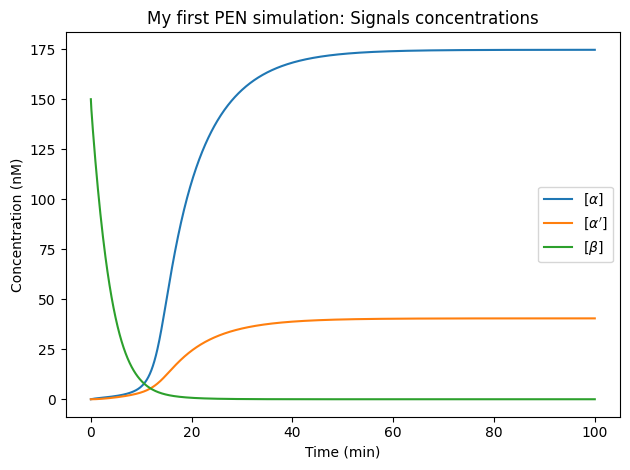

In [6]:
# Signals concentrations

alpha_concentrations=system.concentration_list(y,"alpha", option="alone")       # extract the solution corresponding to alpha
alpha_drained_concentrations=system.concentration_list(y,"alpha", option="drained")       # extract the solution corresponding to alpha
beta_concentrations=system.concentration_list(y,"beta", option="alone")       # extract the solution corresponding to alpha

plt.plot(t,alpha_concentrations, label=r"[$\alpha$]")
plt.plot(t,alpha_drained_concentrations, label=r"[$\alpha'$]")
plt.plot(t,beta_concentrations, label=r"[$\beta$]")

plt.title("My first PEN simulation: Signals concentrations")
plt.xlabel("Time (min)")
plt.legend()
plt.ylabel("Concentration (nM)")
plt.tight_layout()
plt.show()



In this exemple, alpha is linearly produced during the first 40 minutes by cT. Then it is exponentially produced bu the autocatylitic template aT.

Beta is degraded by the exonuclease, but it produces alpha, as cT is irreversible.

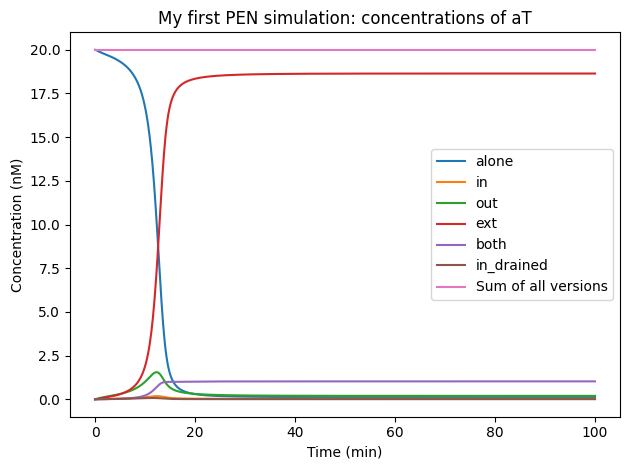

In [7]:
# Template concentrations

aT_alone_concentrations=system.concentration_list(y,"aT", option="alone")
aT_in_concentrations=system.concentration_list(y,"aT", option="in")
aT_out_concentrations=system.concentration_list(y,"aT", option="out")
aT_ext_concentrations=system.concentration_list(y,"aT", option="ext")
aT_both_concentrations=system.concentration_list(y,"aT", option="both")
aT_in_drained_concentrations=system.concentration_list(y,"aT", option="in_drained")
aT_all_concentrations=system.concentration_list(y,"aT", option="all")

plt.plot(t,aT_alone_concentrations, label=r"alone")
plt.plot(t,aT_in_concentrations, label=r"in")
plt.plot(t,aT_out_concentrations, label=r"out")
plt.plot(t,aT_ext_concentrations, label=r"ext")
plt.plot(t,aT_both_concentrations, label=r"both")
plt.plot(t,aT_in_drained_concentrations, label=r"in_drained")
plt.plot(t,aT_all_concentrations, label=r"Sum of all versions")


plt.title("My first PEN simulation: concentrations of aT")
plt.xlabel("Time (min)")
plt.legend()
plt.ylabel("Concentration (nM)")
plt.tight_layout()
plt.show()



The concentrations of all versions vary, but the overall concentration of the converter template stays constant, as it is protected from exonuclease degradation.

## IV. Plot the system to check all species and kinetics

In [8]:
# Print the system

system.print(detailed_kinetics=True, enzymes_kinetic=True)

PEN System Summary
Temperature: 45 °C
Leak rate: 0
Sodium concentration: 0.07 M
Magnesium concentration: 0.0125 M

--------------------------------------------------
Enzyme Concentrations:
  Nb.BsmI concentration: 300 U/µL
  Nt.BstNBI concentration: 10 U/µL
  Polymerase concentration: 30 U/µL
  Exonuclease concentration: 23 nM


--------------------------------------------------
Kinetic Rates Dictionary
--------------------------------------------------
alpha           <-> aT              (input) : k_on = 7.31e-01 nM⁻¹·min⁻¹, k_off = 6.72e+02 min⁻¹
alpha           <-> aT              (output) : k_on = 4.82e-01 nM⁻¹·min⁻¹, k_off = 5.16e+01 min⁻¹
alpha           <-> cT              : k_on = 4.82e-01 nM⁻¹·min⁻¹, k_off = 5.16e+01 min⁻¹
alpha           <-> dT              : k_on = 4.82e-01 nM⁻¹·min⁻¹, k_off = 5.16e+01 min⁻¹
alpha           <-> rT_alpha        : k_on = 6.75e-01 nM⁻¹·min⁻¹, k_off = 2.32e+02 min⁻¹
beta            <-> cT              : k_on = 5.77e-01 nM⁻¹·min⁻¹, k_off = 8.58e+

In [10]:
# Plot the graph representation

# TODO

# A second system: with extended and shortened versions of the signals

In [ ]:
# TODO: plus/minus version

# A second system: experimental code sections

In [ ]:
# TODO: non-protected

# TODO: non-phosĥated


# Experimental section: Simulate the system directly from the sequences

In [ ]:
# TODO